In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from scipy.stats import ttest_ind
#from scipy.stats import mannwhitneyu
#from sklearn.cluster import KMeans

# Functions

In [16]:
def p_to_stars(p):
    if p <= 0.0001:
        return "****"
    elif p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"
    else:
        return "ns"

def add_stat_bracket(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], color="black", linewidth=1)
    ax.text((x1 + x2) / 2, y + h, text, ha="center", va="bottom", fontsize=9)



In [17]:
def beautiful_boxplot(
    df_list,
    labels,
    ylabel=None,
    xlabel=None,
    title=None,
    log_scale=False,
    colors=None,         # list of colors per box (optional)
    dot_size=20,
    jitter=0.06,
    figsize=(4.8, 4.2),
    dpi=200,
    show=True,
    stat_pairs=None
):
    """
    df_list : list of pandas Series (or 1D arrays)
    labels  : list of group names (same length as df_list)
    colors  : list of colors for each box (same length as df_list) or None
    """

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    # Clean data
    data = [np.asarray(d.dropna()) for d in df_list]

    # Boxplot
    bp = ax.boxplot(
        data,
        widths=0.55,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(linewidth=1.5),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        boxprops=dict(linewidth=1.2),
    )

    # Colors per box (or default)
    if colors is None:
        colors = ["lightgray"] * len(data)

    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.55)

    # Overlay jittered dots
    for i, y in enumerate(data, start=1):
        x = np.random.normal(loc=i, scale=jitter, size=len(y))
        ax.scatter(x, y, alpha=0.65, s=dot_size, linewidths=0)

    # Styling
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", direction="out", length=4, width=1, labelsize=9)

    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, fontsize=9)

    if xlabel:
        ax.set_xlabel(xlabel, fontsize=10)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=10)
    if title:
        ax.set_title(title, fontsize=11, pad=10)

    if log_scale:
        ax.set_yscale("log")

    # Add p-value
    if stat_pairs:
        y_max = max([np.nanmax(y) for y in data])
        y_min = min([np.nanmin(y) for y in data])
        y_range = y_max - y_min

        for idx, (x1, x2, p_value) in enumerate(stat_pairs):
            y = y_max + y_range * (0.08 + idx * 0.12)
            h = y_range * 0.04
            stars = p_to_stars(p_value)

            add_stat_bracket(ax, x1, x2, y, h, stars)

        ax.set_ylim(top=y_max + y_range * (0.2 + len(stat_pairs) * 0.12))

    fig.tight_layout()

    if show:
        plt.show()

    return fig, ax

In [ ]:
def _beautiful_boxplot(
    df_list,
    labels,
    ylabel=None,
    xlabel=None,
    title=None,
    log_scale=False,
    colors=None,         # list of colors per box (optional)
    dot_size=20,
    jitter=0.06,
    figsize=(4.8, 4.2),
    dpi=200,
    show=True
):
    """
    df_list : list of pandas Series (or 1D arrays)
    labels  : list of group names (same length as df_list)
    colors  : list of colors for each box (same length as df_list) or None
    """

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    # Clean data
    data = [np.asarray(d.dropna()) for d in df_list]

    # Boxplot
    bp = ax.boxplot(
        data,
        widths=0.55,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(linewidth=1.5),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        boxprops=dict(linewidth=1.2),
    )

    # Colors per box (or default)
    if colors is None:
        colors = ["lightgray"] * len(data)

    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.55)

    # Overlay jittered dots
    for i, y in enumerate(data, start=1):
        x = np.random.normal(loc=i, scale=jitter, size=len(y))
        ax.scatter(x, y, alpha=0.65, s=dot_size, linewidths=0)

    # Styling
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", direction="out", length=4, width=1, labelsize=9)

    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, fontsize=9)

    if xlabel:
        ax.set_xlabel(xlabel, fontsize=10)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=10)
    if title:
        ax.set_title(title, fontsize=11, pad=10)

    if log_scale:
        ax.set_yscale("log")

    fig.tight_layout()

    if show:
        plt.show()

    return fig, ax

# Data import

In [11]:
paths = [
    "/mnt/c/users/elopatukhin/Desktop/all_WT/foci_aggregation.csv",
     "/mnt/c/users/elopatukhin/Desktop/all_PDS_5uM/foci_aggregation.csv"
     ]

dfs = []
for p in paths:
    df = pd.read_csv(p)
    dfs.append(df)
print(f"Loaded {len(dfs)} dataframes.")

Loaded 2 dataframes.


# Boxplots

In [21]:
labels=["Control", "PDS, 5 uM"]
args = [{'var': "n_foci", 'ylabel':'Number of foci', 'title':''}]

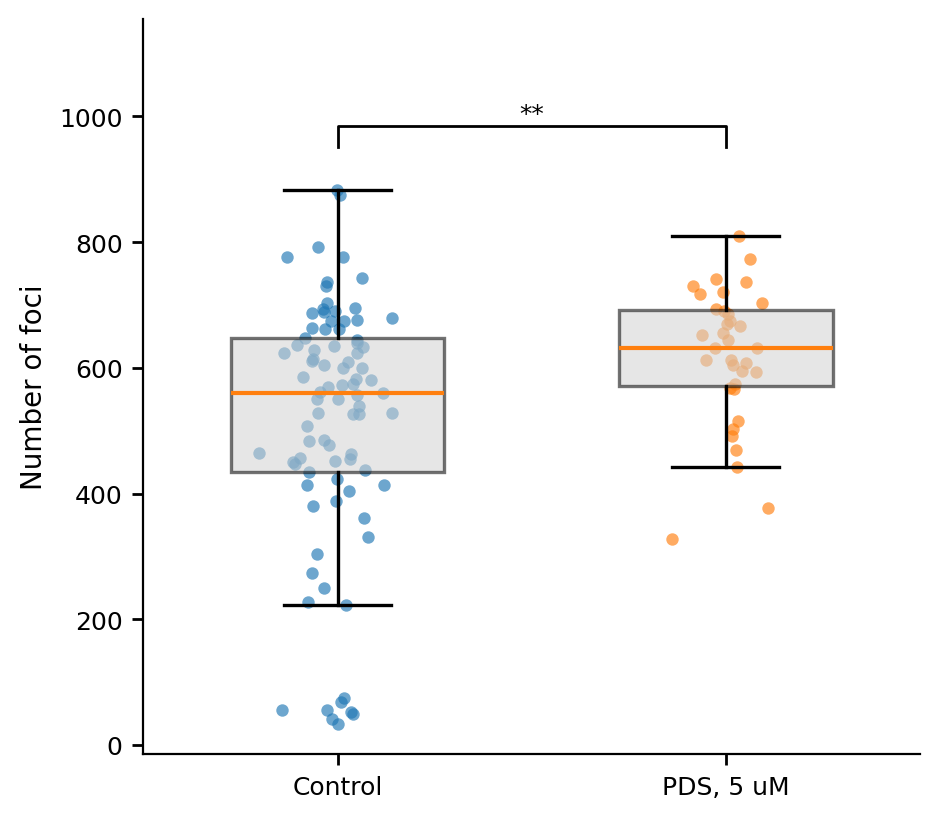

In [22]:
for arg in args:
    beautiful_boxplot(
        df_list=[
                dfs[0][arg['var']],
                dfs[1][arg['var']]
                ],
        labels=labels,
        ylabel=arg['ylabel'],
        title=arg['title'],
        stat_pairs=[
        (1, 2, 0.004)
    ]
    )

# T-test

In [14]:
dfs[0].columns

Index(['filname', 'n_foci', 'sigma_nm_mean', 'sigma_nm_sd',
       'intensity_photon_mean', 'intensity_photon_sd', 'sigma_pixel_mean',
       'sigma_pixel_sd', 'foci_MFI_mean', 'foci_MFI_sd'],
      dtype='str')

In [15]:
reference = dfs[0]
col = "n_foci"

results = []

for i in range(1, len(dfs)):
    group = dfs[i]

    # Drop NaNs
    x = reference[col].dropna()
    y = group[col].dropna()

    t_stat, p_value = ttest_ind(x, y, equal_var=True)

    results.append({
        "comparison": f"dfs[0] vs dfs[{i}]",
        "t_stat": t_stat,
        "p_value": p_value,
        'significant' : p_value < 0.05
    })

for r in results:
    print(r)

{'comparison': 'dfs[0] vs dfs[1]', 't_stat': np.float64(-2.931330425336506), 'p_value': np.float64(0.004048228418778295), 'significant': np.True_}


In [23]:
def compare_to_reference(
    dfs,
    col,
    reference_idx=0,
    equal_var=True,
    alpha=0.05
):
    """
    Compare all dataframes to a reference dataframe using t-test.

    Parameters
    ----------
    dfs : list of pandas DataFrame
    col : str
        Column for comparison
    reference_idx : int
        Index of reference dataframe
    equal_var : bool
        Student t-test if True, Welch t-test if False
    alpha : float
        Significance threshold

    Returns
    -------
    pandas.DataFrame
    """

    reference = dfs[reference_idx]

    results = []

    for i, group in enumerate(dfs):

        if i == reference_idx:
            continue

        x = reference[col].dropna()
        y = group[col].dropna()

        t_stat, p_value = ttest_ind(
            x,
            y,
            equal_var=equal_var
        )

        results.append({
            "comparison": f"dfs[{reference_idx}] vs dfs[{i}]",
            "n_reference": len(x),
            "n_group": len(y),
            "mean_reference": x.mean(),
            "mean_group": y.mean(),
            "std_reference": x.std(),
            "std_group": y.std(),
            "t_stat": t_stat,
            "p_value": p_value,
            "significant": p_value < alpha
        })

    result_df = pd.DataFrame(results)

    result_df["p_value"] = result_df["p_value"].map(lambda x: f"{x:.3e}")
    result_df["t_stat"] = result_df["t_stat"].map(lambda x: f"{x:.3f}")

    return result_df

In [ ]:
stats_df = compare_to_reference(
    dfs,
    col="n_foci"
)

         comparison  n_reference  n_group  mean_reference  mean_group  \
0  dfs[0] vs dfs[1]           86       35      514.465116  619.742857   

   std_reference   std_group  t_stat    p_value  significant  
0     200.499711  108.641705  -2.931  4.048e-03         True  
